# **Phishing**

**Note:** This is a pretty rough first look, but can help decide which is easiest to work w/

**Link:** https://archive.ics.uci.edu/dataset/327/phishing+websites

This is a good dataset, but unfortunately it doesnt have any NaN values or null values. Though, this would be a good option for even decision trees since it seems to be only one of three values [-1, 0, 1], and tbh I am not sure what they represent. Perhaps 0 was the null value, I am unsure.

Also, there seems to be some highly correlated features, such as favicon and popupwindow. Would be a good instance for data handling/feature engineering.

---

In [3]:
# Global imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

In [4]:
# NOTE: Uncomment and run this once, or just refer to the info below

# pip install ucimlrepo

In [5]:
# This is the only thing that really needs to change when looking from dataset to dataset, run everything else that follows as normal

UCI_DATASET_ID = 327   # Phishing Websites
NA_VALUES = None
TOP_K = 30

In [6]:
# Load the data

dataset = fetch_ucirepo(id=UCI_DATASET_ID)
X = dataset.data.features
y = dataset.data.targets
 
df = pd.concat([X, y], axis=1)
TARGET_COL = y.columns[0]  # fetched dynamically, whatever it's actually named
 
print(f"Shape: {df.shape}")
print(f"Target column: '{TARGET_COL}'")
df.head(10)

Shape: (11055, 31)
Target column: 'result'


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,port,https_token,request_url,url_of_anchor,links_in_tags,sfh,submitting_to_email,abnormal_url,redirect,on_mouseover,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,1,-1,1,0,0,-1,-1,-1,0,1,1,1,1,1,1,1,-1,1,-1,-1,1
6,1,0,-1,1,1,-1,-1,-1,1,1,1,1,-1,-1,0,-1,-1,-1,0,1,1,1,1,1,-1,-1,-1,1,0,-1,-1
7,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,0,1,-1
8,1,0,-1,1,1,-1,1,1,-1,1,1,-1,1,0,1,-1,1,1,0,1,1,1,1,1,-1,1,1,1,0,1,1
9,1,1,-1,1,1,-1,-1,1,-1,1,1,1,1,0,1,-1,1,1,0,1,1,1,1,1,-1,0,-1,1,0,1,-1


In [7]:
# Basic info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-null  int64
 14  links_in_tags    

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
having_ip_address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
url_length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
shortining_service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_at_symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
prefix_suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_sub_domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
sslfinal_state,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
domain_registration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0
favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0


In [9]:
if TARGET_COL in df.columns:
    print(df[TARGET_COL].value_counts())
    print()
    print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
else:
    print(f"Column '{TARGET_COL}' not found — update TARGET_COL in the config cell.")

result
 1    6157
-1    4898
Name: count, dtype: int64

result
 1    55.69 %
-1    44.31 %
Name: proportion, dtype: str


In [10]:
# Null value check

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
 
null_summary = (
    pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
 
print(f"Columns with at least one missing value: {len(null_summary)} / {df.shape[1]}")
null_summary.head(30)

Columns with at least one missing value: 0 / 31


,n_missing,pct_missing


In [11]:
top_n_missing = min(25, len(null_summary))
 
if top_n_missing > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, top_n_missing * 0.3)))
    null_summary.head(top_n_missing)["pct_missing"].sort_values().plot(
        kind="barh", ax=ax, color="indianred"
    )
    ax.set_xlabel("% Missing")
    ax.set_title(f"Top {top_n_missing} Columns by Missing Value Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

No missing values found.


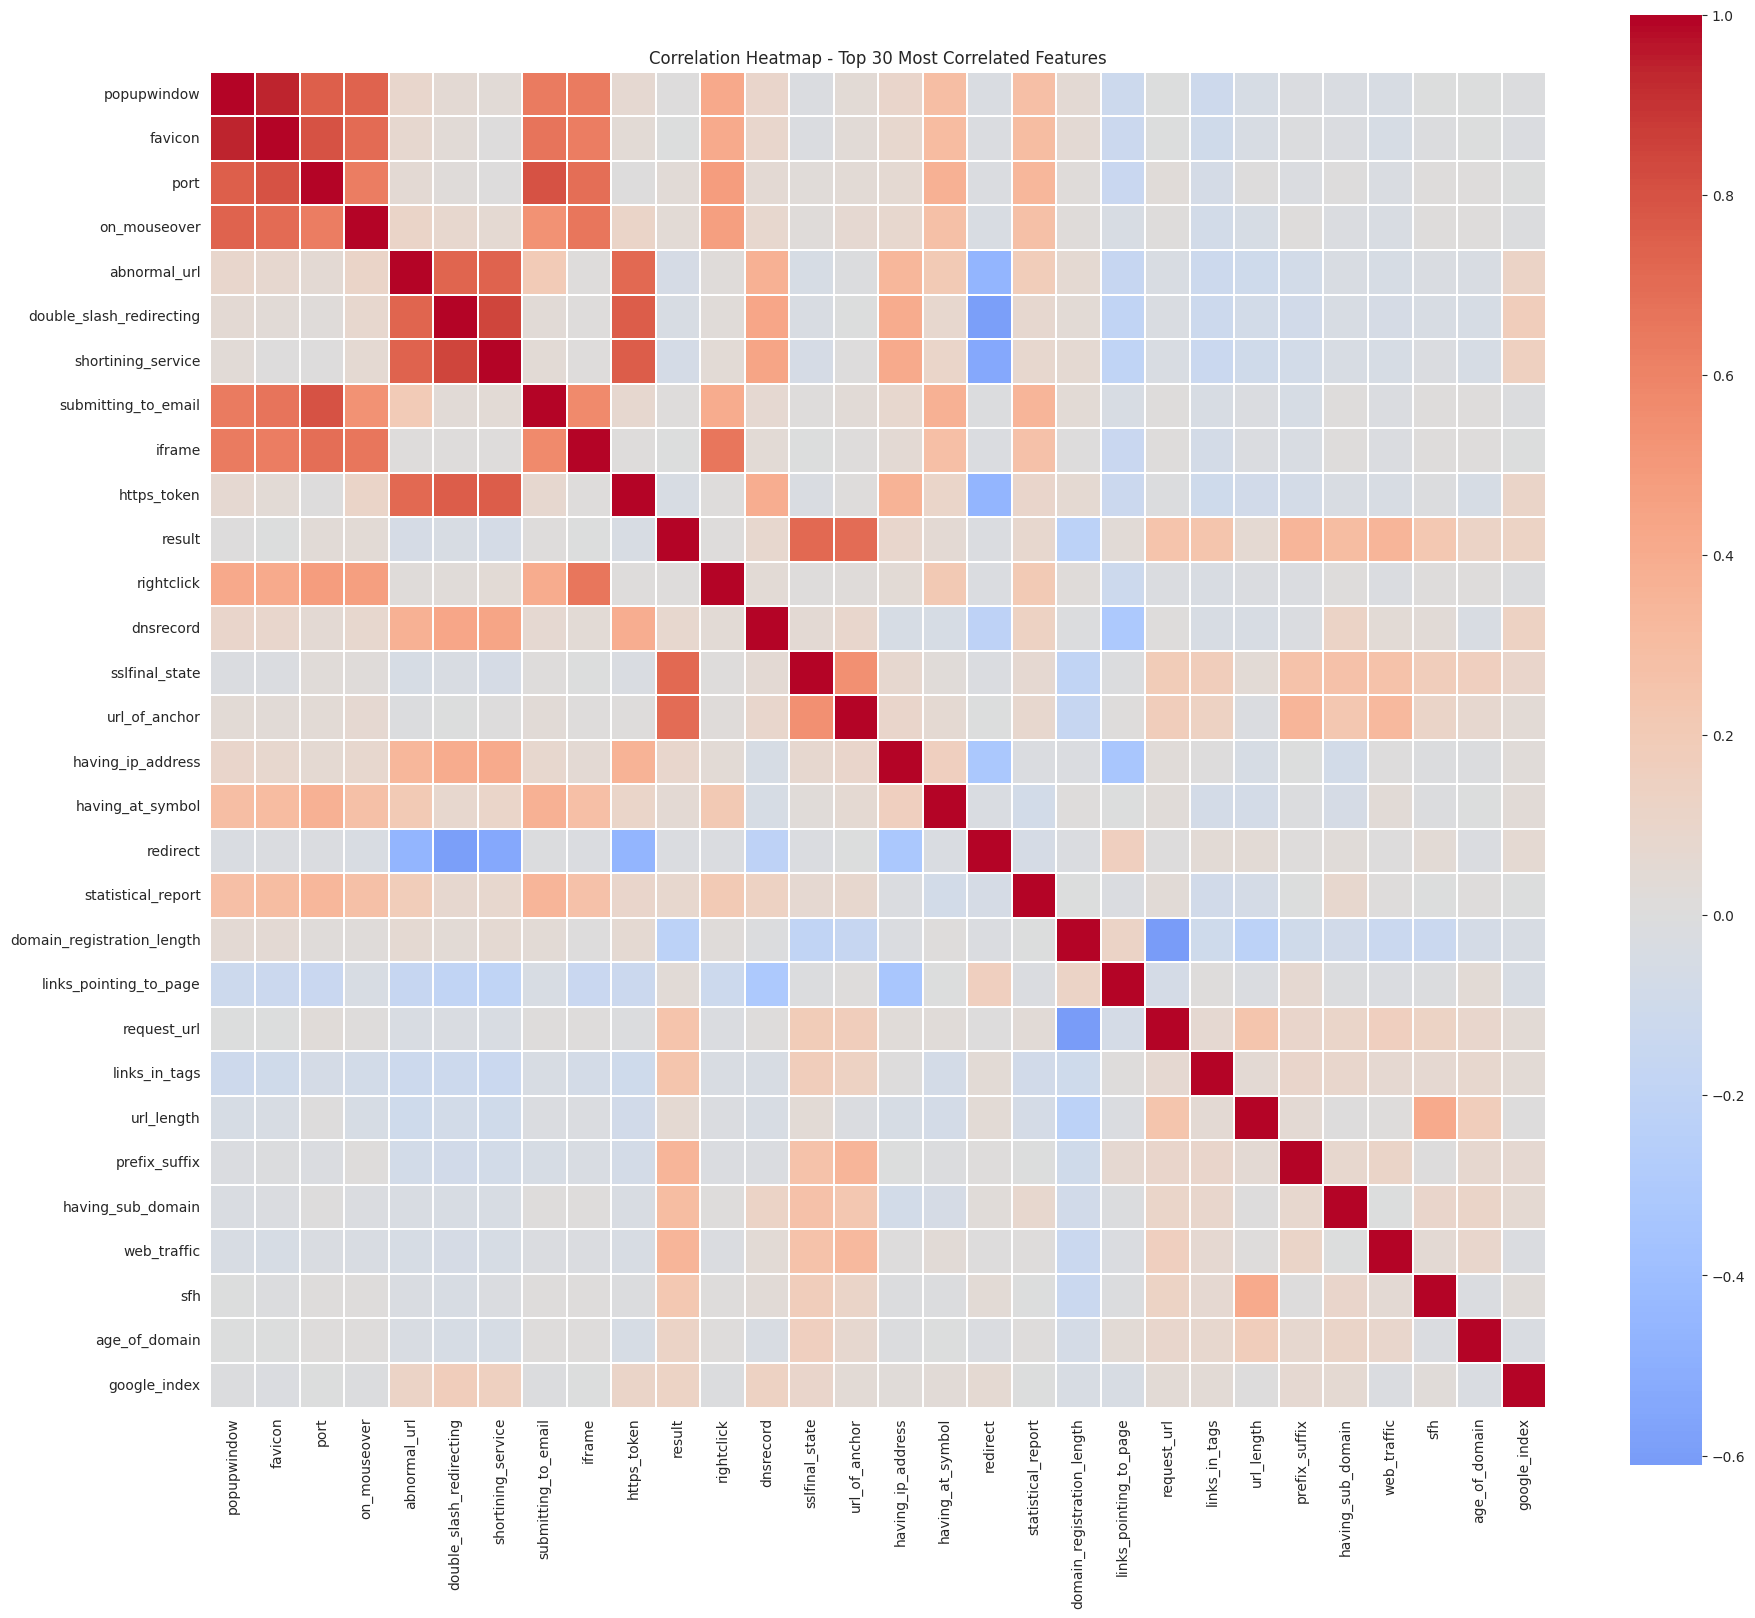

In [12]:
# Correlation heatmap

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
 
if TOP_K is not None and TOP_K < len(numeric_df.columns):
    avg_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
    plot_cols = avg_abs_corr.head(TOP_K).index
    heatmap_title = f"Correlation Heatmap - Top {TOP_K} Most Correlated Features"
else:
    plot_cols = numeric_df.columns
    heatmap_title = "Correlation Heatmap - All Numeric Features"
 
fig, ax = plt.subplots(figsize=(min(24, len(plot_cols) * 0.5 + 4), min(20, len(plot_cols) * 0.5 + 4)))
sns.heatmap(
    corr_matrix.loc[plot_cols, plot_cols],
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title(heatmap_title)
plt.tight_layout()
plt.show()

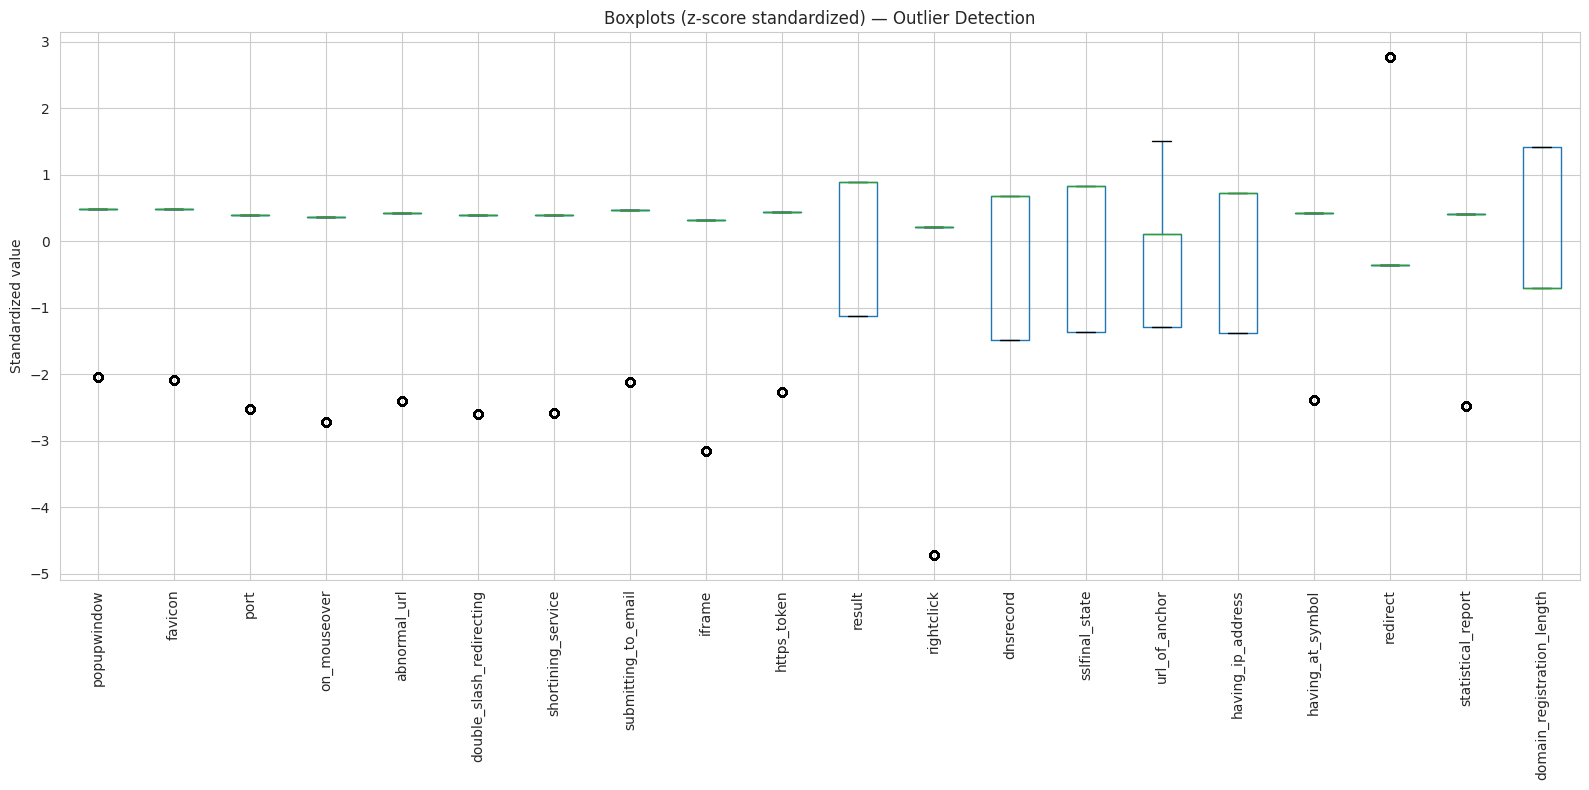

In [13]:
boxplot_cols = plot_cols[:20]  # cap at 20 for readability regardless of TOP_K
standardized = numeric_df[boxplot_cols].apply(zscore, nan_policy="omit")
 
fig, ax = plt.subplots(figsize=(16, 8))
standardized.boxplot(ax=ax, rot=90)
ax.set_title("Boxplots (z-score standardized) — Outlier Detection")
ax.set_ylabel("Standardized value")
plt.tight_layout()
plt.show()

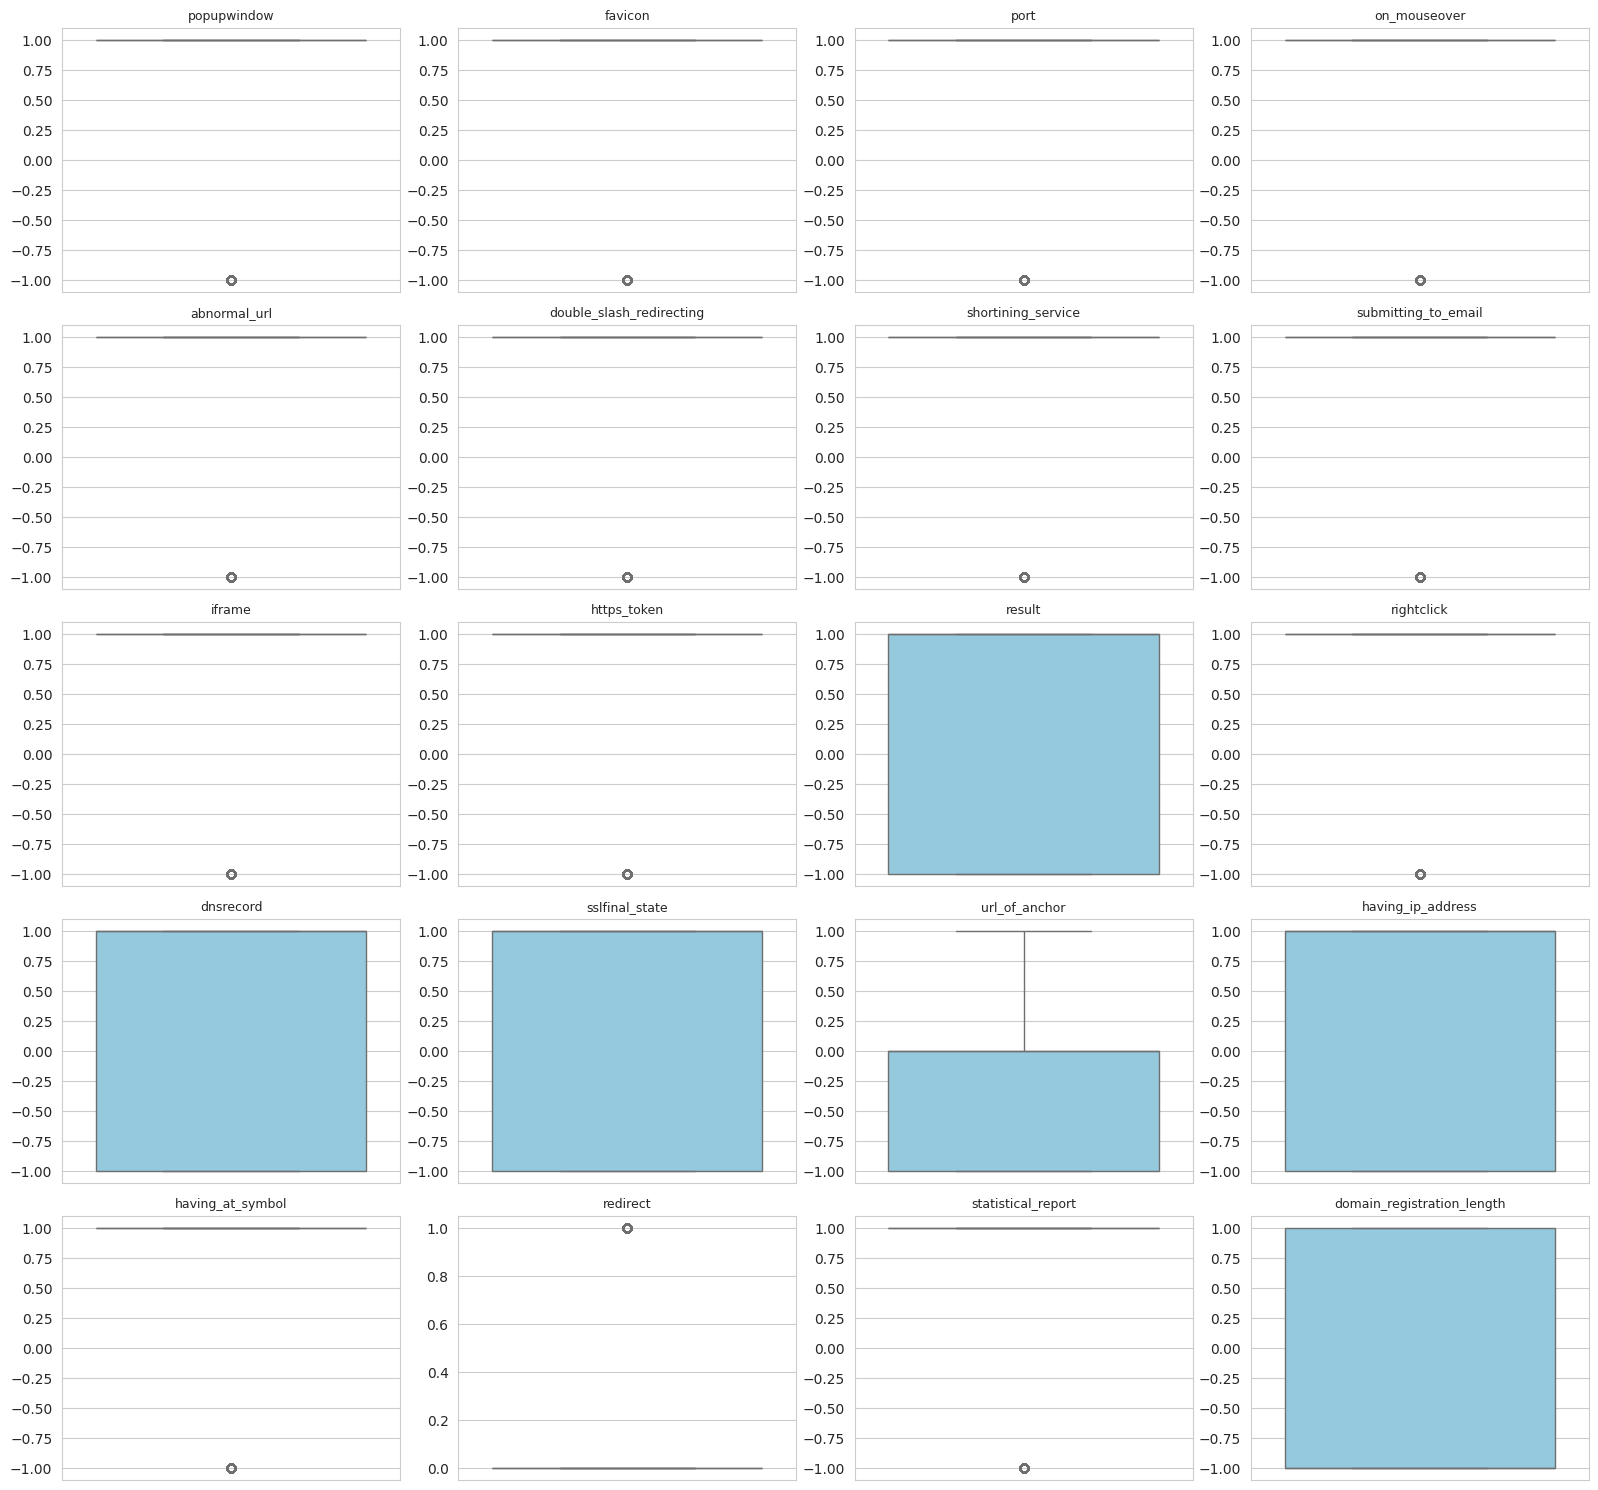

In [14]:
n_cols = 4
n_rows = int(np.ceil(len(boxplot_cols) / n_cols))
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
 
for i, col in enumerate(boxplot_cols):
    sns.boxplot(y=numeric_df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
 
for j in range(len(boxplot_cols), len(axes)):
    axes[j].axis("off")
 
plt.tight_layout()
plt.show()

In [15]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())
 
outlier_counts = (
    numeric_df[boxplot_cols]
    .apply(iqr_outlier_count)
    .sort_values(ascending=False)
    .to_frame("n_outliers")
)
outlier_counts["pct_outliers"] = (outlier_counts["n_outliers"] / len(numeric_df) * 100).round(2)
outlier_counts

,n_outliers,pct_outliers
popupwindow,2137,19.33
favicon,2053,18.57
submitting_to_email,2014,18.22
https_token,1796,16.25
having_at_symbol,1655,14.97
abnormal_url,1629,14.74
statistical_report,1550,14.02
port,1502,13.59
shortining_service,1444,13.06
double_slash_redirecting,1429,12.93
